# Day 01 - Python / NumPy / Pandas / Matplotlib 基础

日期：2026-09-11
目标：为船舶遥感项目打数据处理基础
环境：shipvision (Python 3.10, PyTorch 2.14.0+cpu)

In [3]:
ships=[
    {"name":"ship_a","length":120,"type":"cargo"},
    {"name":"ship_b","length":45,"type":"fishing"},
    {"name":"ship_c","length":300,"type":"tanker"}
]

def classify(length):
    if length<50:
        return "small"
    elif length<200:
        return "medium"
    else:
        return "large"

for s in ships:
    s["size"]=classify(s["length"])

for s in ships:
    print(s)

{'name': 'ship_a', 'length': 120, 'type': 'cargo', 'size': 'medium'}
{'name': 'ship_b', 'length': 45, 'type': 'fishing', 'size': 'small'}
{'name': 'ship_c', 'length': 300, 'type': 'tanker', 'size': 'large'}


In [4]:
import numpy as np

a=np.array([1,2,3,4,5])
b=np.zeros([2,3])
c=np.ones([2,3])
d=np.arange(0,10,2)
e=np.linspace(0,1,5)
f=np.random.randn(3,4)

print("a:",a)
print("b:\n",b)
print("c:\n",c)
print("d:",d)
print("e:",e)
print("f shape:",f.shape)


a: [1 2 3 4 5]
b:
 [[0. 0. 0.]
 [0. 0. 0.]]
c:
 [[1. 1. 1.]
 [1. 1. 1.]]
d: [0 2 4 6 8]
e: [0.   0.25 0.5  0.75 1.  ]
f shape: (3, 4)


In [9]:
x=np.arange(12).reshape(3,4)
print("x:\n",x)
print("x[0]",x[0])
print("x[:,1]",x[:,1])
print("x[1,2]",x[1,2])
print("x>5\n",x>5)
print("x[x>5]",x[x>5])
print("x转置:\n",x.T)

x:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
x[0] [0 1 2 3]
x[:,1] [1 5 9]
x[1,2] 6
x>5
 [[False False False False]
 [False False  True  True]
 [ True  True  True  True]]
x[x>5] [ 6  7  8  9 10 11]
x转置:
 [[ 0  4  8]
 [ 1  5  9]
 [ 2  6 10]
 [ 3  7 11]]


In [10]:
import pandas as pd

data={
    "ship_id":["s1","s2","s3","s4","s5"],
    "length":[120,45,300,80,210],
    "type":["cargo","fishing","tanker","cargo","tanker"],
    "confidence":[0.9,0.85,0.97,0.78,0.93]
}

df=pd.DataFrame(data)
print(df)
print(df.info())
print(df.describe())

  ship_id  length     type  confidence
0      s1     120    cargo        0.90
1      s2      45  fishing        0.85
2      s3     300   tanker        0.97
3      s4      80    cargo        0.78
4      s5     210   tanker        0.93
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ship_id     5 non-null      object 
 1   length      5 non-null      int64  
 2   type        5 non-null      object 
 3   confidence  5 non-null      float64
dtypes: float64(1), int64(1), object(2)
memory usage: 288.0+ bytes
None
           length  confidence
count    5.000000    5.000000
mean   151.000000    0.886000
std    103.585713    0.073689
min     45.000000    0.780000
25%     80.000000    0.850000
50%    120.000000    0.900000
75%    210.000000    0.930000
max    300.000000    0.970000


In [13]:
A=np.random.randn(2,3)
B=np.random.randn(3,4)
C=A @ B
print("A@B shape:",C.shape)
print("mean:",A.mean())
print("std:",A.std())
print("sum axis=0:",A.sum(axis=0))
print("max axis=1:",A.max(axis=1))

A@B shape: (2, 4)
mean: 0.16727345522490925
std: 0.5232343894222674
sum axis=0: [-0.13370867  0.15878458  0.97856482]
max axis=1: [0.70336852 0.44055899]


In [14]:
print("长度>100:\n",df[df["length"]>100])

print("按长度排序:\n",df.sort_values("length",ascending=False))

print("按类型分组:\n",df.groupby("type")["length"].mean())

df["size"]=df["length"].apply(classify)
print(df)

长度>100:
   ship_id  length    type  confidence
0      s1     120   cargo        0.90
2      s3     300  tanker        0.97
4      s5     210  tanker        0.93
按长度排序:
   ship_id  length     type  confidence
2      s3     300   tanker        0.97
4      s5     210   tanker        0.93
0      s1     120    cargo        0.90
3      s4      80    cargo        0.78
1      s2      45  fishing        0.85
按类型分组:
 type
cargo      100.0
fishing     45.0
tanker     255.0
Name: length, dtype: float64
  ship_id  length     type  confidence    size
0      s1     120    cargo        0.90  medium
1      s2      45  fishing        0.85   small
2      s3     300   tanker        0.97   large
3      s4      80    cargo        0.78  medium
4      s5     210   tanker        0.93   large


In [16]:
df2=df.copy()
df2.loc[1,"confidence"]=np.nan
df2.loc[3,"type"]=None

print("缺失情况:\n",df2.isna().sum())
print("缺失值处理:\n",df2.fillna({"confidence":0.0,"type":"unknown"}))


缺失情况:
 ship_id       0
length        0
type          1
confidence    1
size          0
dtype: int64
缺失值处理:
   ship_id  length     type  confidence    size
0      s1     120    cargo        0.90  medium
1      s2      45  fishing        0.00   small
2      s3     300   tanker        0.97   large
3      s4      80  unknown        0.78  medium
4      s5     210   tanker        0.93   large


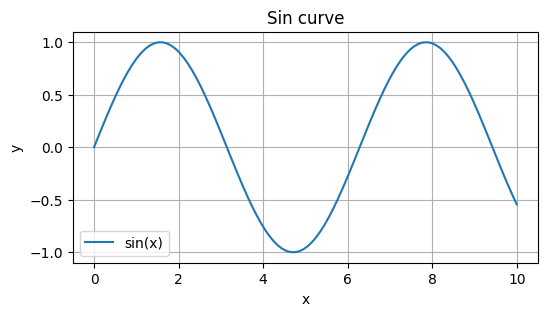

In [17]:
import matplotlib.pyplot as plt

x=np.linspace(0,10,100)
y=np.sin(x)
plt.figure(figsize=(6,3))
plt.plot(x,y,label="sin(x)")
plt.title("Sin curve")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

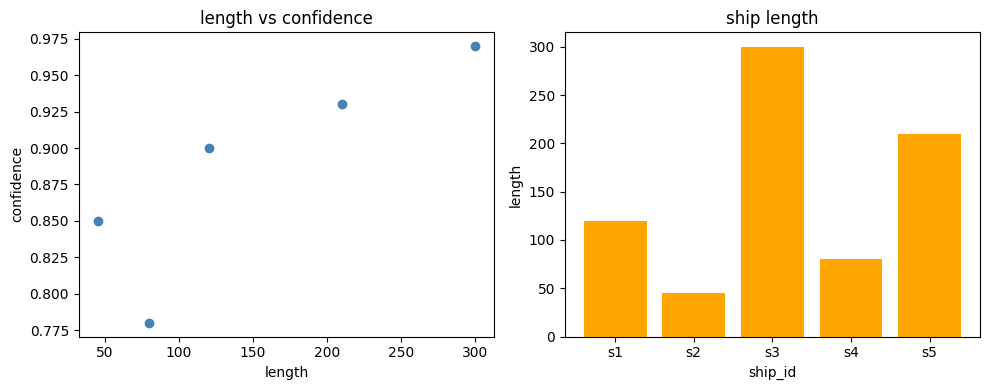

In [19]:
import matplotlib.pyplot as plt
fig,axes=plt.subplots(1,2,figsize=(10,4))

axes[0].scatter(df["length"],df["confidence"],c="steelblue")
axes[0].set_title("length vs confidence")
axes[0].set_xlabel("length")
axes[0].set_ylabel("confidence")

axes[1].bar(df["ship_id"],df["length"],color="orange")
axes[1].set_title("ship length")
axes[1].set_xlabel("ship_id")
axes[1].set_ylabel("length")

plt.tight_layout()
##plt.saveifig()
plt.show()

高置信度数量: 46
type
cargo      190.867470
fishing    194.509434
tanker     176.890625
Name: length, dtype: float64


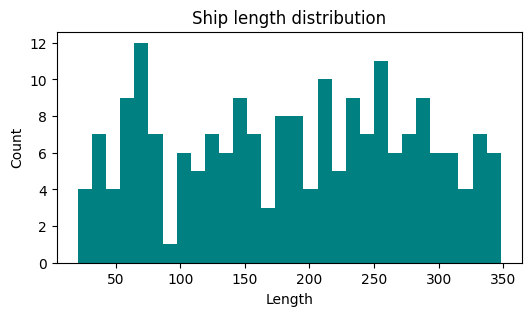

In [25]:
np.random.seed(42)
n=200

detections=pd.DataFrame({
    "ship_id":[f"ship_{i}" for i in range(n)],
    "length":np.random.randint(20,350,n),
    "confidence":np.random.uniform(0.5,1.0,n),
    "type":np.random.choice(["cargo","fishing","tanker"],n)
})

high_conf=detections[detections["confidence"]>0.9]
print("高置信度数量:",len(high_conf))

print(detections.groupby("type")["length"].mean())

plt.figure(figsize=(6,3))
plt.hist(detections["length"],bins=30,color="teal")
plt.title("Ship length distribution")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()